A. Considere el sistema eléctrico de la figura con ecuación:

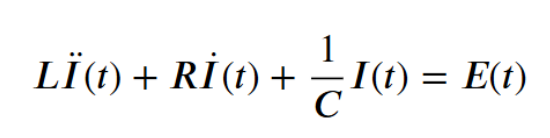

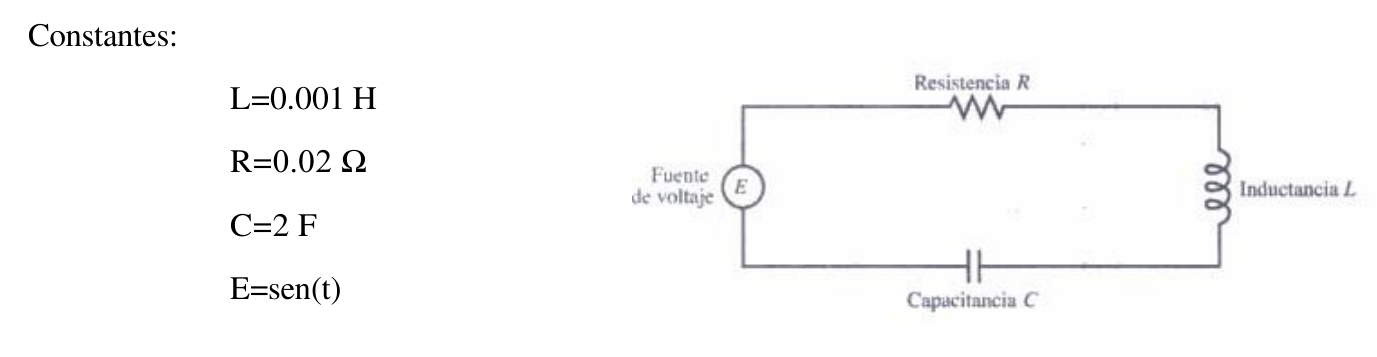

Suponga condiciones iniciales iguales a cero y un tiempo total de simulación de 15 s.

1. Obtenga la función de transferencia del sistema.

2. Cree el modelo usando Python, de dos formas diferentes y compare (Mediante ecuaciones
diferenciales y función de transferencia)

3. Encuentre la gráfica de corriente, pero ahora ingresando las constantes desde el archivo
“parámetros.txt” en Python.

4. Guarde la respuesta anterior como una imagen.

5. Modifique el modelo para que la entrada E sea creada en un .txt y utilizada en la función
de simulación.

Punto 1. $1/(LS^2 +RS + 1/C)$

solve_ivp(fun, t_span, y0, method='RK45', t_eval=None, args=None)

Parámetros de entrada principales

fun : Función creada en el numeral anterior

t_span : Intervalo de integración para resolver las ecuaciones diferenciales (t0, tf). En
este caso t0 = 0 y tf = 15 s.

y0 : Vector con condiciones iniciales. En este caso la posición inicial es 0 m y la
velocidad inicial es -1m/s.

method : Parámetro opcional que indica el método de integración utilizado. Por
defecto es el método de Runge-Kutta (RK45)

t_eval : Parmámetro opcional. Tiempo en el que se almacenará la solución, por lo que
debe estar dentro del rango t_span . Si no se agrega, se utilizará una cantidad de
puntos seleccionados por el solucionador.

args : Parámetro opcional. Representa los argumentos adicionales para pasarle a la
función definida en fun .

Punto 2.


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
import scipy.signal as signal


#METODO 1

def metodo1 (t, y, L,R,C): #Siempre va de primero t e Y, y luego van las constantes.

    #Ahora definimos la entrada, que es un vector con las mismas dimensiones del vector del tiempo
    En = np.sin(t)

    #Aqui se ponen las ecuaciones obtenidas en la primera parte escrita
    i1,i2 = y #y[0] = i (corrietne), y[1] = dx/dt (corriente)
    d_i1 = i2
    d_i2 = (En/L) - ((R/L)*i2) - ((1/(C*L))*i1)
    return [d_i1,d_i2]

#Listo, en lo anterior, plantee las ecuaciones ahora, necesito resolverlo

t_s = (0, 15) #Tiempo total
y0 = [0, 0] #Entonces condiciones iniciales para i1 e i2, respectivamente
t_e = np.arange(0, 15 + 0.1, 0.1) #En este caso asumimos este Periodo de muestreo 
L = 0.001
R = 0.02
C = 2

sol = integrate.solve_ivp(metodo1, t_s, y0, method='RK45', t_eval=t_e, args=(L,R,C))

tiempo = sol.t 
corriente = sol.y[0]
D_corriente = sol.y[1]

Text(0, 0.5, 'Corriente derivada')

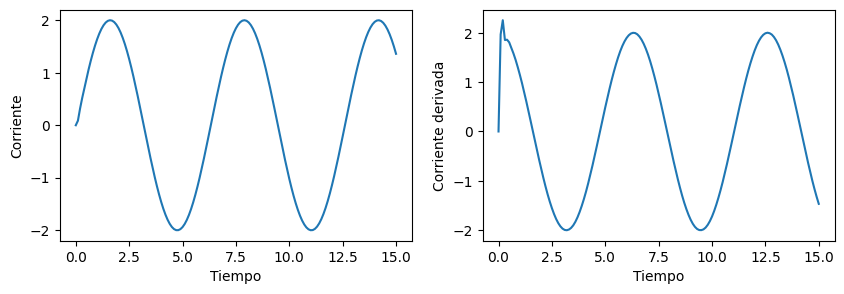

In [34]:
# Gráfica de la solución
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(tiempo, corriente)
plt.xlabel('Tiempo')
plt.ylabel('Corriente')
plt.subplot(1, 2, 2)
plt.plot(tiempo, D_corriente)
plt.xlabel('Tiempo')
plt.ylabel('Corriente derivada')

In [35]:
#Metodo 2

# Coeficientes del numerador y denominador
# de la fn de transferencia
Valor_0 = 1/C
num = [1,0]
den = [L, R, Valor_0]
# Entrada = En
E = np.sin(t_e)
# Creación del sistema
sys = signal.TransferFunction(num, den)
t_out, y_out, _ = signal.lsim(sys,E , T=t_e)

Text(0, 0.5, 'Corriente')

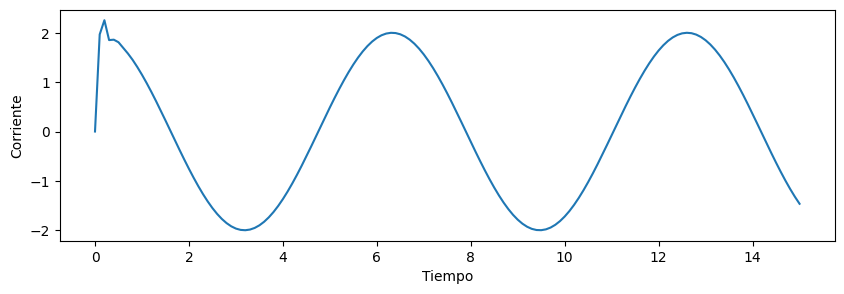

In [36]:
plt.figure(figsize=(10, 3))
plt.plot(t_out, y_out)
plt.xlabel('Tiempo')
plt.ylabel('Corriente')

Las dos gráficas muestran un comportamiento **prácticamente igual para la corriente**, con una oscilación sinusoidal alrededor de cero y una amplitud cercana a \(2\), lo que indica que ambos métodos representan correctamente la dinámica del circuito. La diferencia más evidente aparece al inicio en la solución por **ecuación diferencial**, donde se observa un pequeño comportamiento transitorio y una forma ligeramente más irregular antes de estabilizarse, mientras que la **función de transferencia** presenta una respuesta más suave desde el comienzo. Esto ocurre porque la ecuación diferencial se resuelve numéricamente a partir de las **condiciones iniciales** y de las derivadas, por lo que puede aparecer un pequeño transitorio numérico, mientras que la función de transferencia describe directamente la relación entrada-salida del sistema y, bajo las condiciones asumidas, muestra principalmente la respuesta correspondiente a la entrada. En general, ambos métodos son consistentes y llegan prácticamente a la misma respuesta.


Punto 3.

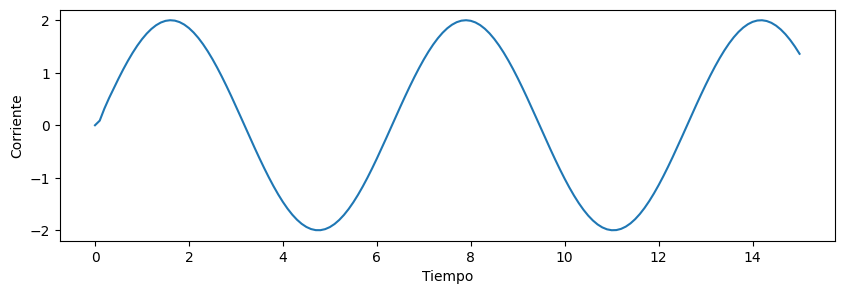

In [37]:
#extraigo la info del .txt

parametros = np.loadtxt("parametros.txt")

# Coeficientes del numerador y denominador
# de la fn de transferencia
L = parametros[0]
R = parametros[1]
C = parametros[2]
Valor_0 = 1/C
num = [1]
den = [L, R, Valor_0]
# Entrada = En
E = np.sin(t_e)
# Creación del sistema
sys = signal.TransferFunction(num, den)
t_out, y_out, _ = signal.lsim(sys,E , T=t_e)
plt.figure(figsize=(10, 3))
plt.plot(t_out, y_out)
plt.xlabel('Tiempo')
plt.ylabel('Corriente')
plt.savefig("Corriente_Parametrostxt") #PUNTO 4

PUNTO 5

Text(0, 0.5, 'Corriente derivada')

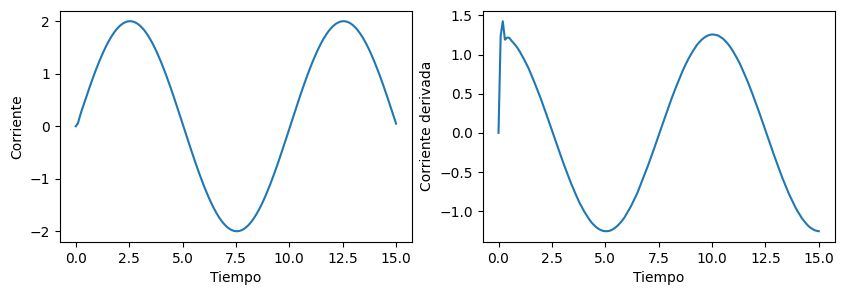

In [38]:
from scipy.interpolate import interp1d

datos = np.loadtxt("Entrada.txt")
tiempo_txt = datos[:,0]
Entrada_txt = datos[:,1]

Funcion_entrada = interp1d(tiempo_txt, Entrada_txt, fill_value="extrapolate")

def metodo1 (t, y, L,R,C): #Siempre va de primero t e Y, y luego van las constantes.

    #Ahora definimos la entrada, que es un vector con las mismas dimensiones del vector del tiempo
    En = Funcion_entrada(t)

    #Aqui se ponen las ecuaciones obtenidas en la primera parte escrita
    i1,i2 = y #y[0] = i (corrietne), y[1] = dx/dt (corriente)
    d_i1 = i2
    d_i2 = (En/L) - ((R/L)*i2) - ((1/(C*L))*i1)
    return [d_i1,d_i2]

#Listo, en lo anterior, plantee las ecuaciones ahora, necesito resolverlo

t_s = (0, 15) #Tiempo total
y0 = [0, 0] #Entonces condiciones iniciales para i1 e i2, respectivamente
t_e = np.arange(0, 15 + 0.1, 0.1) #En este caso asumimos este Periodo de muestreo 
L = 0.001
R = 0.02
C = 2

sol = integrate.solve_ivp(metodo1, t_s, y0, method='RK45', t_eval=t_e, args=(L,R,C))

tiempo = sol.t 
corriente = sol.y[0]
D_corriente = sol.y[1]

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(tiempo, corriente)
plt.xlabel('Tiempo')
plt.ylabel('Corriente')
plt.subplot(1, 2, 2)
plt.plot(tiempo, D_corriente)
plt.xlabel('Tiempo')
plt.ylabel('Corriente derivada')

# **PUNTO B**

Text(0, 0.5, 'Velocidad')

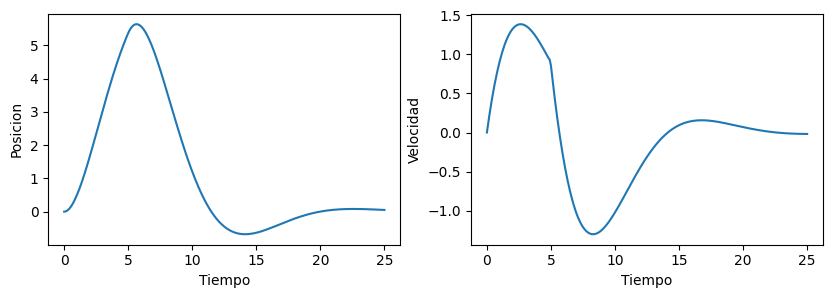

In [39]:
def metodo1_b (t, y, c,m,k): #Siempre va de primero t e Y, y luego van las constantes.

    #Ahora definimos la entrada, que es un vector con las mismas dimensiones del vector del tiempo
    F = np.where(t<=5, 1.2,0) 

    #Aqui se ponen las ecuaciones obtenidas en la primera parte escrita
    x1,x2 = y #y[0] = i (posicion), y[1] = dx/dt (velocidad)
    d_x1 = x2
    d_x2 = (F/m) - ((k/m)*x1) - ((c/m)*x2)
    return [d_x1,d_x2]

#Listo, en lo anterior, plantee las ecuaciones ahora, necesito resolverlo

t_s = (0, 25) #Tiempo total
y0 = [0, 0] #Entonces condiciones iniciales para i1 e i2, respectivamente
t_e = np.arange(0, 25 + 0.1, 0.1) #En este caso asumimos este Periodo de muestreo 
K = 0.2
M = 1
C = 0.5

sol_b = integrate.solve_ivp(metodo1_b, t_s, y0, method='RK45', t_eval=t_e, args=(C,M,K))

tiempo = sol_b.t 
corriente = sol_b.y[0]
D_corriente = sol_b.y[1]

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(tiempo, corriente)
plt.xlabel('Tiempo')
plt.ylabel('Posicion')
plt.subplot(1, 2, 2)
plt.plot(tiempo, D_corriente)
plt.xlabel('Tiempo')
plt.ylabel('Velocidad')

Text(0, 0.5, 'Posicion')

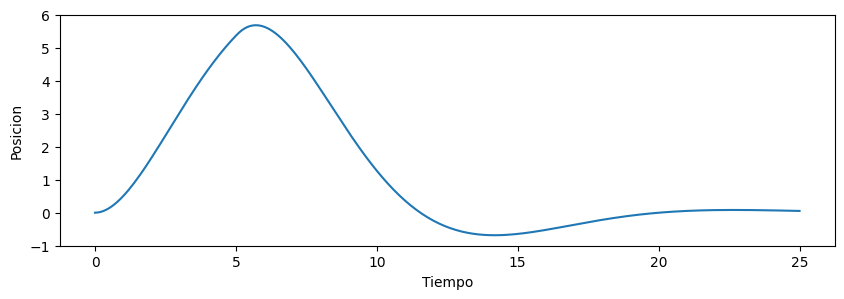

In [40]:
K = 0.2
M = 1
C = 0.5

num = [1]
den = [M, C, K]
#Tiempo = t_e

# Entrada 
F = np.where(t_e<=5, 1.2,0) 
# Creación del sistema
sys = signal.TransferFunction(num, den)
t_out, y_out, _ = signal.lsim(sys,F , T=t_e)
plt.figure(figsize=(10, 3))
plt.plot(t_out, y_out)
plt.xlabel('Tiempo')
plt.ylabel('Posicion')
